
Ex8 - Mobina Haghshenas - 402125057



# Data Preprocessing

## Import libraries & Load data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv(r"Pumpkin_Seeds_Datase.csv")
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik


## Handle missing values

In [21]:
df.isnull().sum()

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Convex_Area          0
Equiv_Diameter       0
Eccentricity         0
Solidity             0
Extent               0
Roundness            0
Aspect_Ration        0
Compactness          0
Class                0
dtype: int64

There is no missing value.

## Encode categorical features

In [22]:
dtypes = df.dtypes
categorical_cols = dtypes[dtypes == 'O'].index.tolist()
for cols in categorical_cols :
    print(f' Unique Values of {cols} are: \n {df[cols].value_counts()} \n')

 Unique Values of Class are: 
 Class
Çerçevelik       1300
Ürgüp Sivrisi    1200
Name: count, dtype: int64 



In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for cols in categorical_cols:
    df[cols] = le.fit_transform(df[cols])

## Feature scaling

In [32]:
#Normalized dataset using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_min_max_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for easier handling
df_min_max_scaled = pd.DataFrame(df_min_max_scaled, columns=df.columns)
df = df_min_max_scaled
# Verify the normalization
mins = df.min()
maxs = df.max()

In [33]:
# Re-checking min-max scaling
mins = df.min()
maxs = df.max()
print("Minimum values of features after min-max scaling:")
print(mins)
print("\nMaximum values of features after min-max scaling:")
print(maxs)

Minimum values of features after min-max scaling:
Area                 0.0
Perimeter            0.0
Major_Axis_Length    0.0
Minor_Axis_Length    0.0
Convex_Area          0.0
Equiv_Diameter       0.0
Eccentricity         0.0
Solidity             0.0
Extent               0.0
Roundness            0.0
Aspect_Ration        0.0
Compactness          0.0
Class                0.0
dtype: float64

Maximum values of features after min-max scaling:
Area                 1.0
Perimeter            1.0
Major_Axis_Length    1.0
Minor_Axis_Length    1.0
Convex_Area          1.0
Equiv_Diameter       1.0
Eccentricity         1.0
Solidity             1.0
Extent               1.0
Roundness            1.0
Aspect_Ration        1.0
Compactness          1.0
Class                1.0
dtype: float64


#  Exploratory Data Analysis (EDA)

## Visualize data

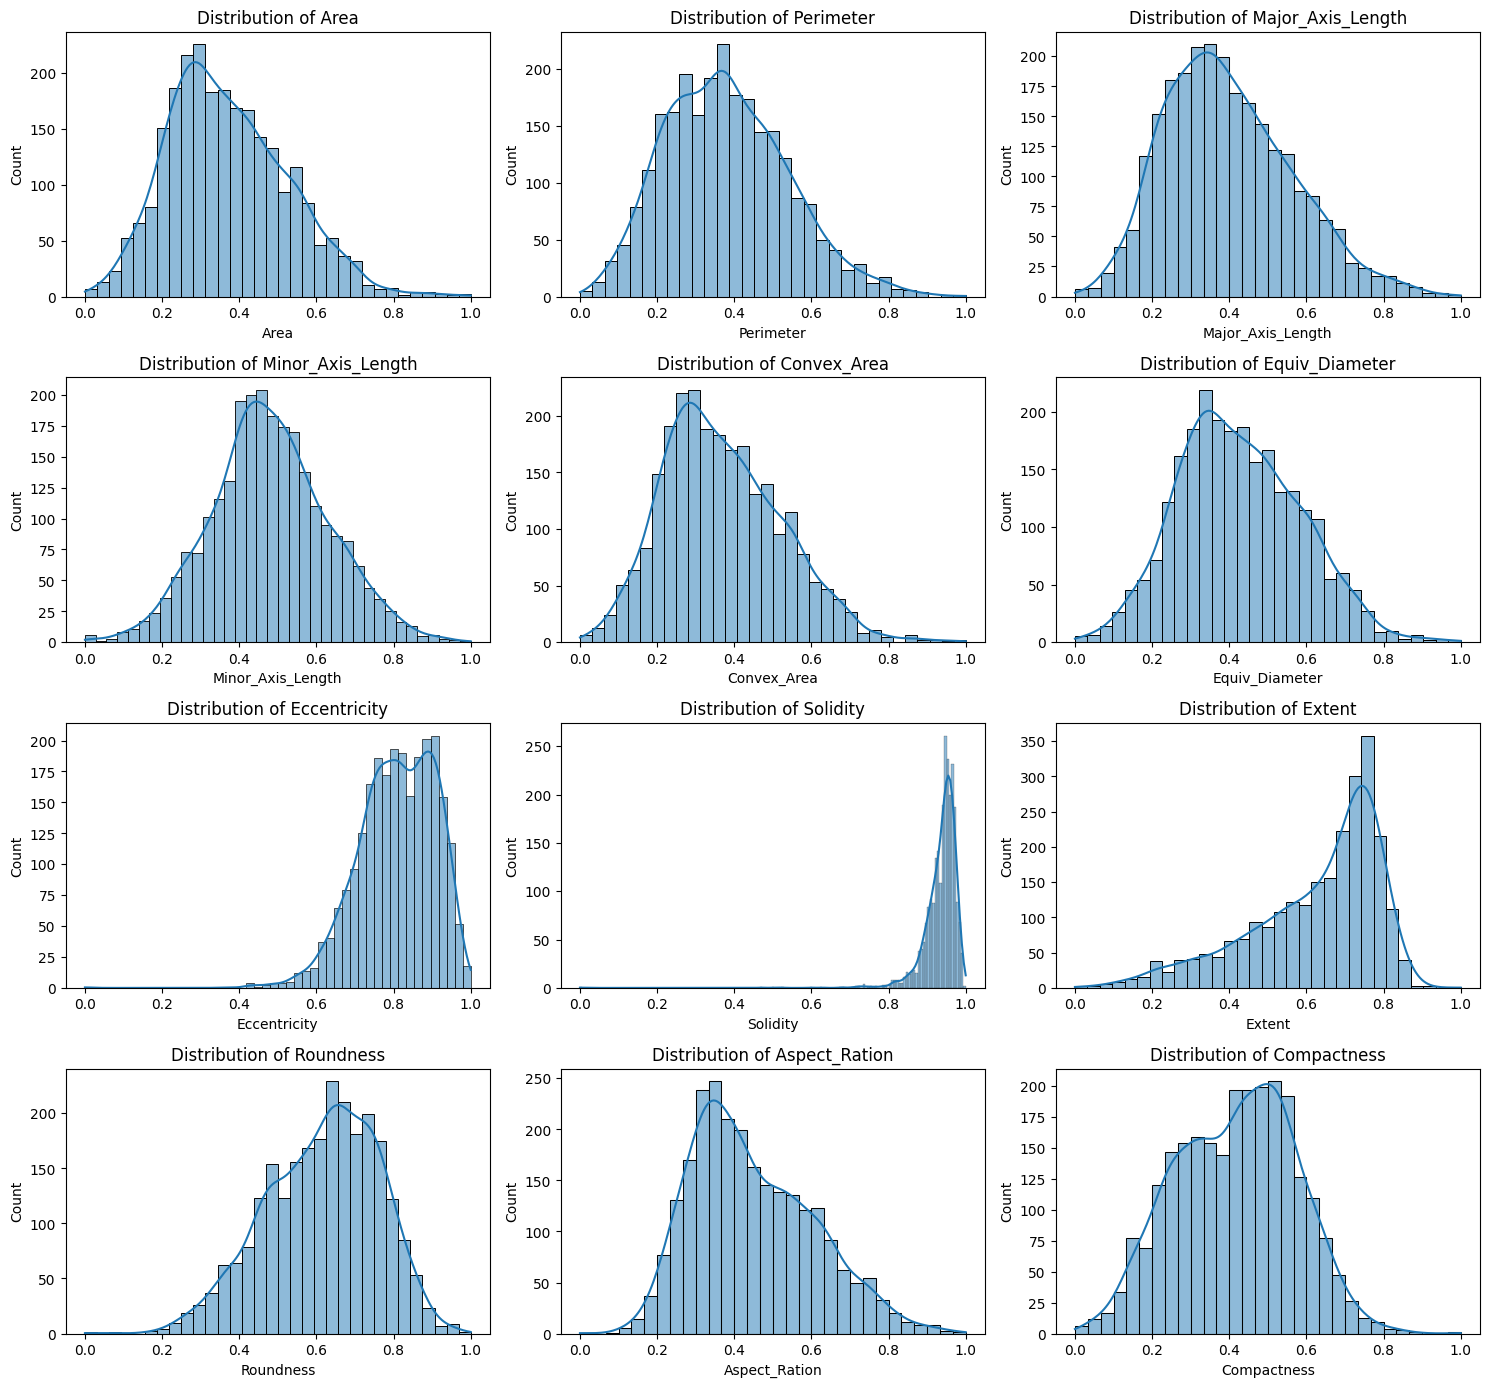

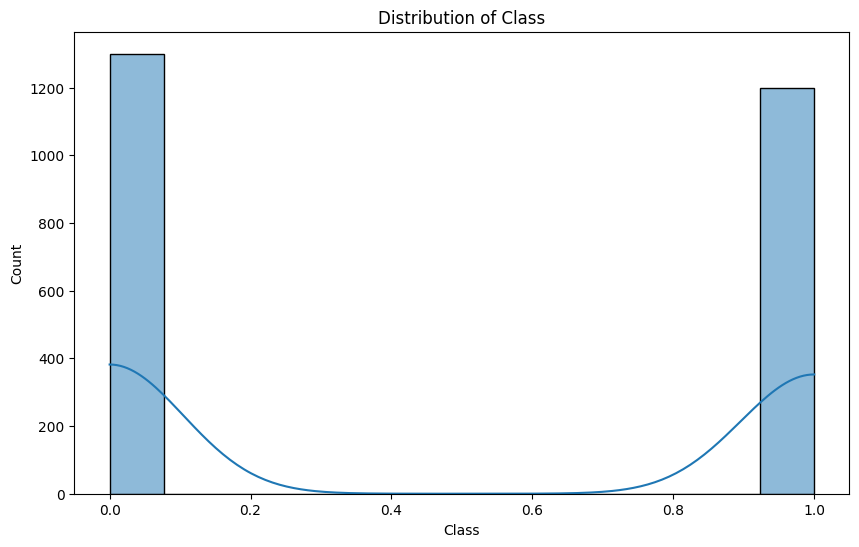

In [34]:
# Number of features
num_features = len(df.columns) - 1

# Create subplots for histograms
fig, axes = plt.subplots(nrows=num_features//3 + 1, ncols=3, figsize=(15, 4*num_features//3 + 1))
axes = axes.flatten()

for i, column in enumerate(df.columns[:-1]):  # exclude the target variable
    sns.histplot(df[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Visualizing the target variable
target_column = df.columns[-1]

# Histogram for the target variable
plt.figure(figsize=(10, 6))
sns.histplot(df[target_column], kde=True)
plt.title(f'Distribution of {target_column}')
plt.show()

## Identify potential relationships

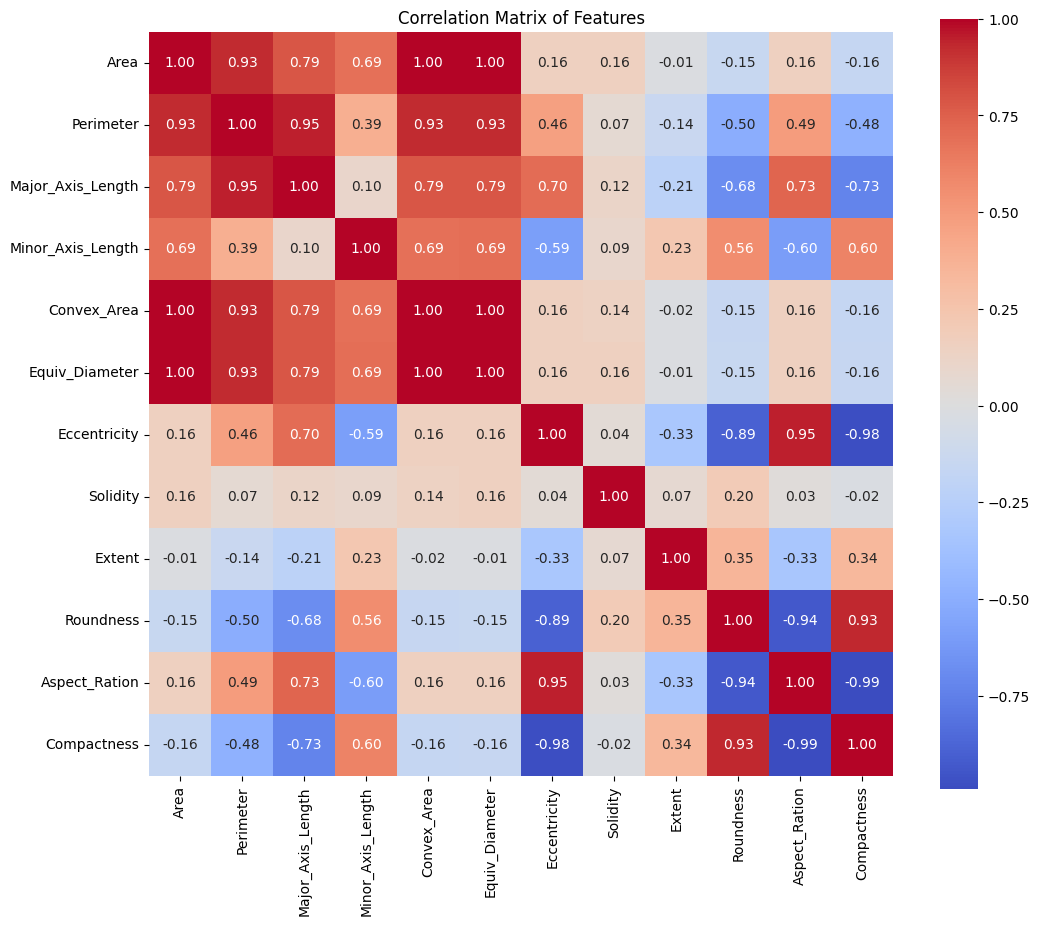

In [35]:
# Extract features (excluding the last column which is the target)
features = df.iloc[:, :-1]

# Correlation Analysis
correlation_matrix = features.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix of Features')
plt.show()

## Analyze class distribution

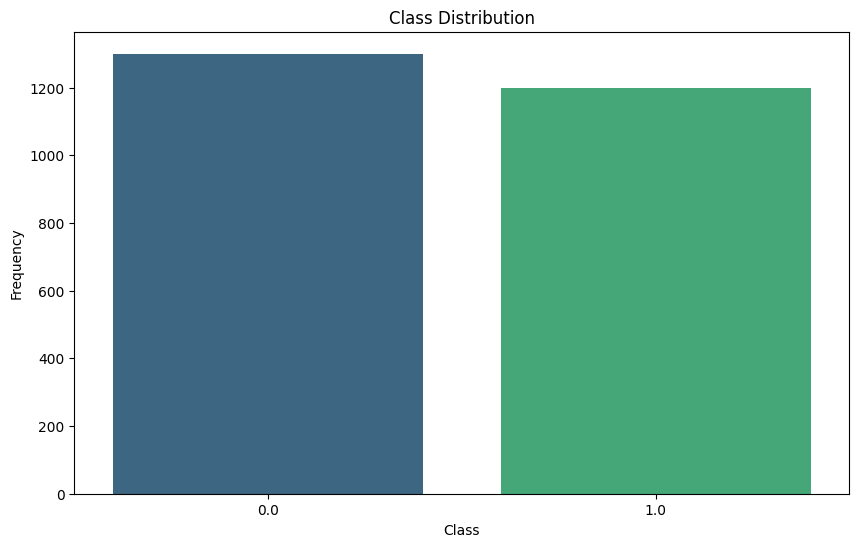

Class counts:
 Class
0.0    1300
1.0    1200
Name: count, dtype: int64


In [36]:
# Extract target variable
target = df.iloc[:, -1]

# Calculate class distribution
class_counts = target.value_counts()

# Plot class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# Print class counts
print("Class counts:\n", class_counts)

In [37]:
#Oversampling with SMOTE
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check the new class distribution
print("Class distribution after SMOTE:\n", pd.Series(y_resampled).value_counts())

Class distribution after SMOTE:
 Class
0.0    1300
1.0    1300
Name: count, dtype: int64


In [38]:
# Combine resampled features and target into a new DataFrame
feature_columns = df.columns[:-1]
target_column = df.columns[-1]
df_resampled = pd.DataFrame(X_resampled, columns=feature_columns)
df_resampled[target_column] = y_resampled

df = df_resampled

## Identify potential outliers

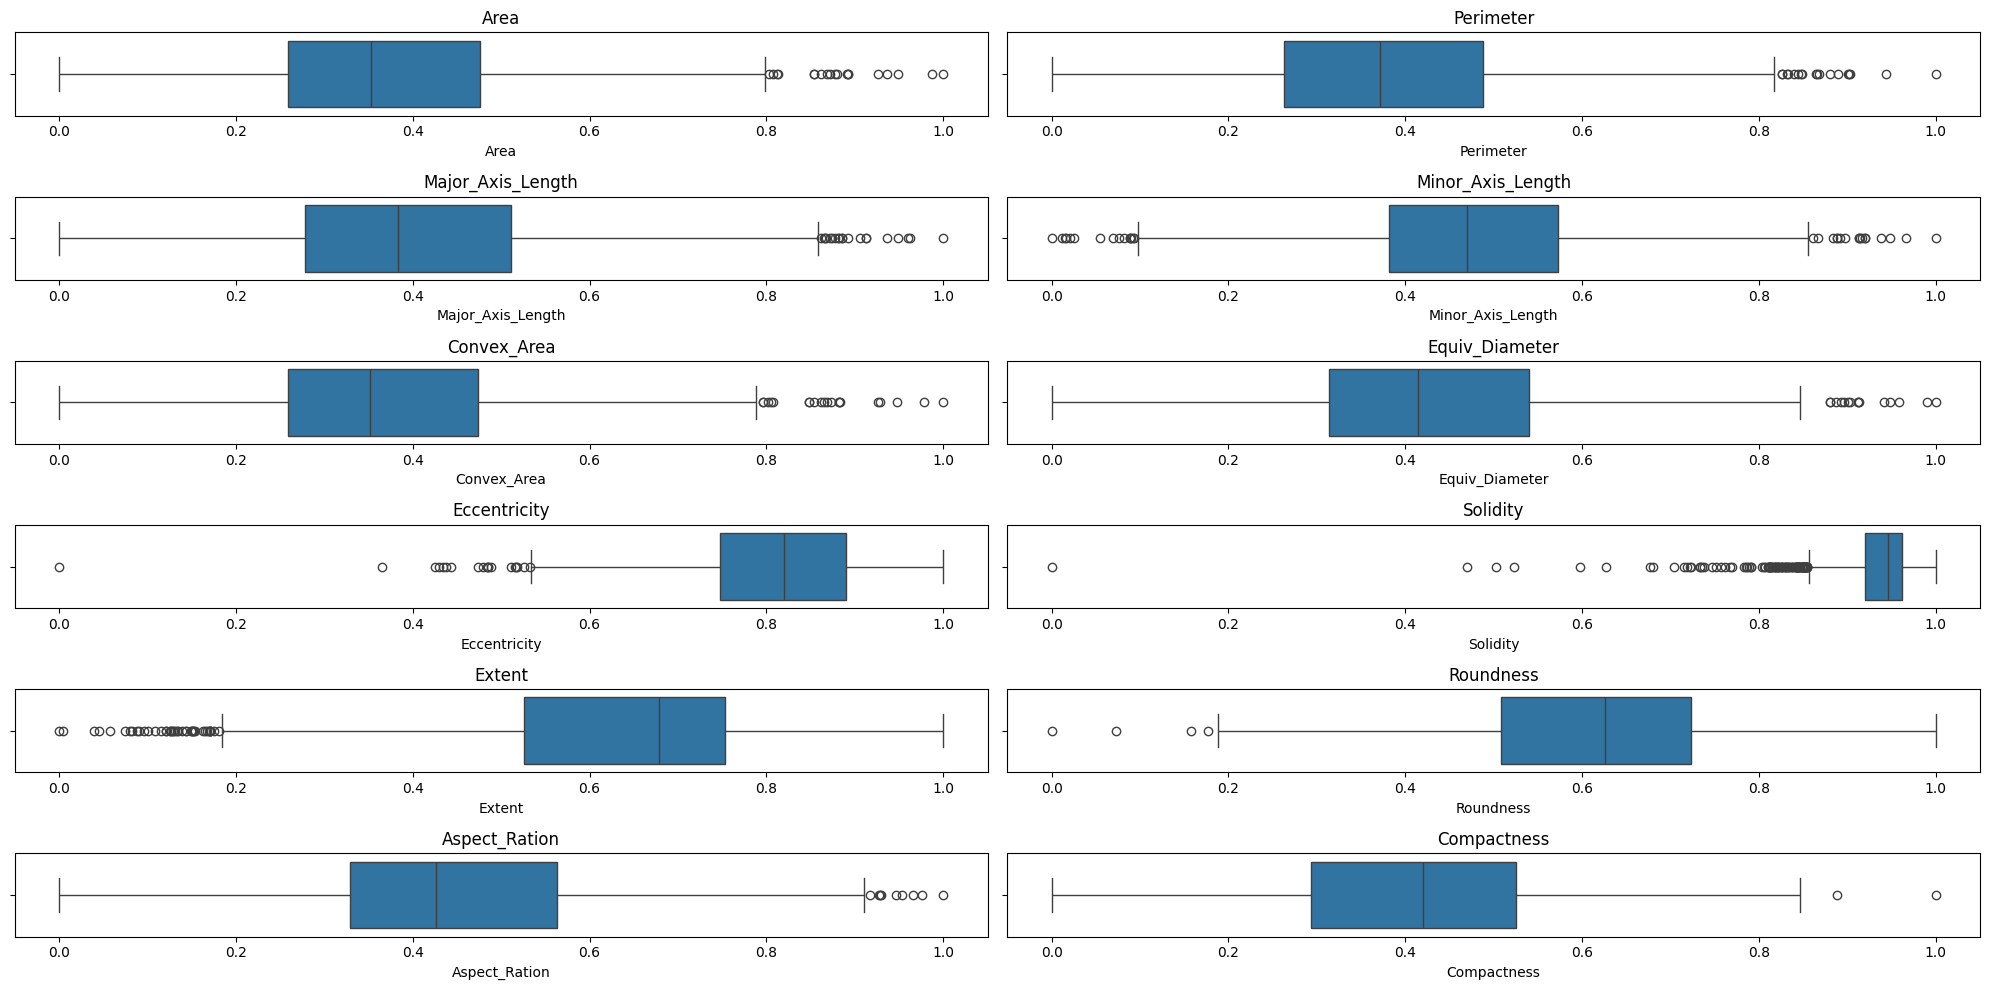

In [45]:
fig, axes = plt.subplots(6, 2, figsize=(20, 10))

# Loop through integer columns and create boxplots on subplots
for col, ax in zip(feature_columns, axes.flat):
    sns.boxplot(x=col, data=df, ax=ax)
    ax.set_title(col)  # Set title for each subplot

plt.tight_layout()

plt.show()

As we can see, there are lots of outliers, I'll just remove them.

In [46]:
for col in feature_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  # Define the upper and lower bounds for outliers
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Remove outliers
  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Model Selection

## Train-test split:

In [50]:
X = df.drop(['Class'], axis=1)
y = df['Class']

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

## Build a Random Forest model & Train the model

In [52]:
from sklearn.ensemble import RandomForestClassifier
# instantiate the classifier
rfc = RandomForestClassifier(random_state=0)
# fit the model
rfc.fit(X_train, y_train)
# Predict the Test set results
y_pred = rfc.predict(X_test)

## Evaluate the model

In [53]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8857545839210155
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.92      0.89       360
         1.0       0.91      0.85      0.88       349

    accuracy                           0.89       709
   macro avg       0.89      0.89      0.89       709
weighted avg       0.89      0.89      0.89       709



# Model Tuning and Evaluation


In [62]:
hist = []
for est in [10,100,200,250,300,350]:
    for samp in [2,5,10]:
        rfc = RandomForestClassifier(n_estimators = est, min_samples_split = samp)
        rfc.fit(X_train, y_train)
        y_pred = rfc.predict(X_test)
        hist.append([est,samp,accuracy_score(y_test, y_pred)])
hist = sorted(hist, key = lambda x:x[2])

In [63]:
hist = hist[-5:]

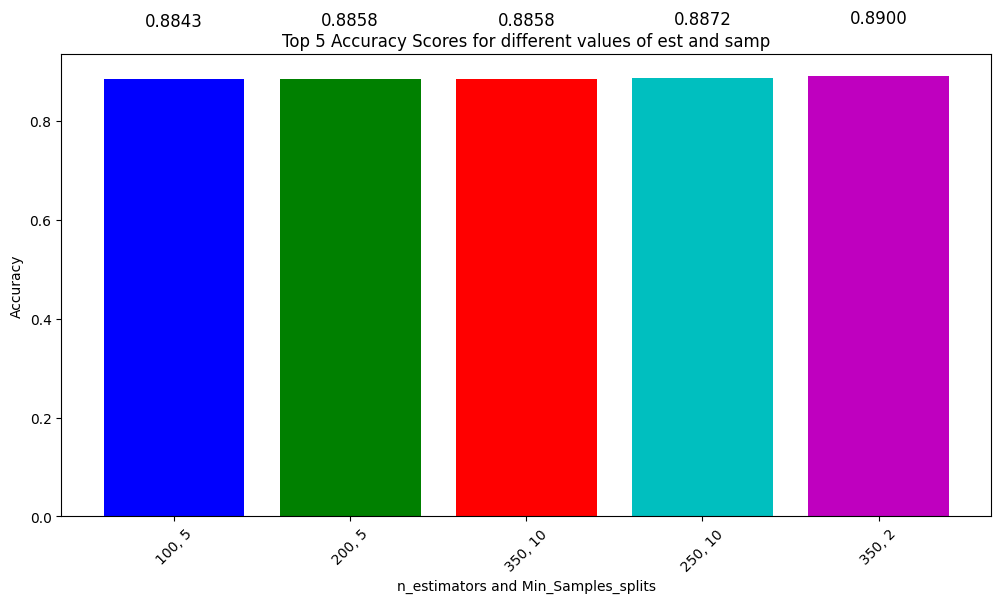

In [64]:
labels = [f"{item[0]}, {item[1]}" for item in hist]
heights = [item[2] for item in hist]

plt.figure(figsize=(12,6))
plt.bar(labels, heights, color = ['b','g','r','c','m',])

for i, (v, label) in enumerate(zip(heights, labels)):
    plt.text(i, v+0.1, f"{v:.4f}", ha='center', va='bottom', fontsize=12)


plt.xlabel("n_estimators and Min_Samples_splits")
plt.ylabel("Accuracy")
plt.title("Top 5 Accuracy Scores for different values of est and samp")
plt.xticks(rotation = 45)
plt.show()

As we can see, a n_estimators and Min_Sample_Splits of 350 and 2 provide the best accuracy among all tested parameter values.
That would be our taken model and lets have a look on that.

In [65]:
from sklearn.metrics import confusion_matrix, classification_report
rfc = RandomForestClassifier(n_estimators = 250, min_samples_split = 2)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(f'Accuracy of the model is: {accuracy_score(y_test, y_pred):.4f}')
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n', cm, '\n')
print('Classification report\n\n', classification_report(y_test,y_pred))

Accuracy of the model is: 0.8886
Confusion matrix

 [[331  29]
 [ 50 299]] 

Classification report

               precision    recall  f1-score   support

         0.0       0.87      0.92      0.89       360
         1.0       0.91      0.86      0.88       349

    accuracy                           0.89       709
   macro avg       0.89      0.89      0.89       709
weighted avg       0.89      0.89      0.89       709



# Final Analysis


## Feature importance

In [66]:
feature_scores = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_scores

Eccentricity         0.201807
Aspect_Ration        0.191654
Compactness          0.183771
Roundness            0.095543
Major_Axis_Length    0.065420
Solidity             0.055615
Minor_Axis_Length    0.047146
Extent               0.038050
Perimeter            0.036803
Convex_Area          0.028719
Equiv_Diameter       0.027775
Area                 0.027698
dtype: float64

Eccentricity        
Aspect_Ration        
Compactness          
Roundness            
Major_Axis_Length
are top 5.
As I expected from EDA, Features with high correlation has less importance.(We can just consider one of them. Such as Major_Axis_Length)

 **Based on your EDA or domain knowledge, are there any additional features
you could engineer from the existing data that might improve model performance?
How might these features capture a different aspect of the pumpkin seed morphology and potentially aid classification?**

It totally depends on pumpkin seed's nature and agricultural knowledge.But several features are suggested:

1. Texture Ratio
2. Color Distribution
3. Surface Roughness
4. Seed Surface Features

These engineered features can capture a different aspect of pumpkin seed morphology and potentially aid classification by providing more nuanced information, capturing subtle differences, and highlighting the importance of surface roughness and micro-structure.

How sensitive are the feature importance scores to changes in hyperparameter settings? Would you expect the most important features to change significantly with different model configurations?

**Random Forest models are sensitive to changes in hyperparameter settings, which can affect the accuracy of feature importance scores. Factors such as the number of trees, maximum depth, and minimum samples split can influence the sensitivity of feature importance scores. However, the most important features tend to remain consistent across different model configurations, especially in low-dimensional data with uncorrelated features and well-regularized models.**
